# 03 — Generalizability and impact: does the reachability method transfer, and what is it good for?

**The question this notebook answers.** Notebooks 01–02 built and validated a convex-cone *reachability oracle* on one dataset — a genome-scale CRISPRi Perturb-seq screen in primary human CD4⁺ T cells (`GWCD4i.DE_stats.h5ad`). It asks whether a desired transcriptomic target state **d** lies inside the cone of states reachable by non-negative combinations of *measured* perturbation effects **E**, and returns a null-calibrated verdict, a minimal recipe, and — when the state is out of reach — a Farkas certificate naming the genes no combination can supply.

Three questions follow naturally, and this notebook takes each one in turn with real computation, not assertion:

1. **Is the method confined to this repo's dataset?** (No — and we prove it by running the *identical* `reachability.py` on a structurally different screen.)
2. **Is there an opportunity to leverage other public datasets?** (Yes — a catalog of 13 real, live-retrieved accessions across five perturbation modalities, each with the specific reachability question it enables.)
3. **What can it be used to resolve in other biological problems?** (A four-direction application map — cross-cell-type screens, drug-combination design, cell reprogramming, and disease-reversal/target-discovery — grounded in live tractability data.)

The live demo is the load-bearing part, so it comes first.

---
## Part 1 — The generalization argument, run live on a second dataset

We apply the reachability oracle, **unchanged**, to **GSE133344** — Norman, Weissman et al. 2019, *Science* (PMID 31395745): a **K562** cell line screened with **CRISPRa** (gene *activation*, gain-of-function) in a **combinatorial** design (single- and double-guide perturbations). This differs from the T-cell screen on three axes simultaneously — cell type, perturbation modality (activation vs knockdown), and combinatorial structure — which makes it a genuine out-of-distribution test rather than a re-run.

### Setup
Import the method module from the repo root and set self-contained plotting styles (the notebook does not depend on any external styling skill). `reachability.py` imports only NumPy and SciPy — no domain code, no GPU, no training.

In [ ]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from scipy.optimize import nnls

sys.path.insert(0, "..")                          # repo root -> reachability.py
import reachability as R

CACHE = "cache"; FIG = "figures"; RESULTS = "../results"
os.makedirs(FIG, exist_ok=True)
BUNDLE = os.path.join(CACHE, "norman_effect_bundle.npz")

# self-contained publication styling (mirrors notebook 02 — no external skill dependency)
plt.rcParams.update({"figure.dpi":110,"font.size":8,"axes.titlesize":9,"axes.labelsize":8,
                     "xtick.labelsize":7,"ytick.labelsize":7,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.25})
FOCAL, NEU, WARN, GOOD = "#1f5fa6", "#8a8f98", "#c1666b", "#4c956c"

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na * nb > 0 else 0.0

print("reachability module loaded:", [f for f in dir(R) if not f.startswith('_')][:6], "...")
print("bundle present:", os.path.exists(BUNDLE))

reachability module loaded: ['ActivationCertificate', 'HeldOutResult', 'NullResult', 'Optional', 'ReachResult', 'SignedReachResult'] ...
bundle present: True


### Load the pre-built effect bundle
The 1.1 GB GEO count matrix was pseudobulked once (CPM+log1p vs 9,702 control cells; top-2000 highly-variable genes; per-gene standardized) and checkpointed to `norman_effect_bundle.npz`, so this notebook is CPU-cheap and reproducible without re-downloading. Rows of **E_s** are single-gene *activations*; **E_d** holds the double-perturbation states in the same gene space.

In [ ]:
# Load the pre-built, verified Norman-2019 (GSE133344) effect bundle.
# It was built ONCE from the 1.1 GB GEO count matrix (CPM+log1p pseudobulk vs 9,702 control
# cells; top-2000 HVG; per-gene standardized) and checkpointed, so this notebook is CPU-cheap
# and fully reproducible without re-downloading. Provenance is in norman_demo_manifest.json.
b = np.load(BUNDLE, allow_pickle=True)
Es          = b["Es"].astype(np.float64)          # (104, 2000) standardized SINGLE-perturbation dictionary
Ed          = b["Ed"].astype(np.float64)          # (130, 2000) DOUBLE-perturbation states, same space
lfc_s, lfc_d = b["lfc_s"].astype(np.float64), b["lfc_d"].astype(np.float64)  # raw log-FC (interpretable)
sing_labels = b["sing_labels"].astype(str)
doub_labels = b["doub_labels"].astype(str)
genes_hvg   = b["genes_hvg"].astype(str)
comp_idx    = b["comp_idx"]; comp_ok = b["comp_ok"].astype(bool)

print(f"single-perturbation dictionary  E_s : {Es.shape}  (rows = CRISPRa activations, cols = HVG)")
print(f"double-perturbation states      E_d : {Ed.shape}")
print(f"gene axis (shared HVG space)         : {genes_hvg.size} genes")
print(f"additivity-testable doubles          : {int(comp_ok.sum())} of {doub_labels.size}")
print(f"\ndataset: GSE133344 = Norman, Weissman et al. 2019 (Science), PMID 31395745")
print( "         K562 cells | CRISPRa (gain-of-function) | combinatorial single + double perturbations")
print( "differs from the repo's CD4+ T-cell screen on THREE axes: cell type, modality, combinatorial design")

single-perturbation dictionary  E_s : (104, 2000)  (rows = CRISPRa activations, cols = HVG)
double-perturbation states      E_d : (130, 2000)
gene axis (shared HVG space)         : 2000 genes
additivity-testable doubles          : 126 of 130

dataset: GSE133344 = Norman, Weissman et al. 2019 (Science), PMID 31395745
         K562 cells | CRISPRa (gain-of-function) | combinatorial single + double perturbations
differs from the repo's CD4+ T-cell screen on THREE axes: cell type, modality, combinatorial design


### Orientation gate — the sign-mirror of the T-cell check
The T-cell screen was CRISPRi, so its integrity gate required each knockdown to *lower* its own gene. This screen is CRISPRa, so the mirror-image check applies: each activation must *raise* its own gene. Passing this gate is what licenses treating the matrix as a real, correctly-oriented effect basis.

In [ ]:
# Orientation gate (the sign-mirror of the T-cell CRISPRi gate).
# The T-cell screen was CRISPRi: a knockdown must LOWER its own gene (own-gene z strongly negative).
# This screen is CRISPRa: an activation must RAISE its own gene. Check it before trusting anything.
gpos = {g:i for i,g in enumerate(genes_hvg)}
own = []
for k,l in enumerate(sing_labels):
    if l in gpos:
        own.append(lfc_s[k, gpos[l]])
own = np.array(own)
print("=== ORIENTATION GATE (CRISPRa: activation should RAISE its own gene) ===")
print(f"  own-gene log-FC over {own.size} singles whose target is in the HVG space:")
print(f"    median {np.median(own):+.3f} | {(own>0).mean():.0%} positive | {(own>1).mean():.0%} above +1")
assert np.median(own) > 0.5, "orientation check FAILED — activation should raise its own gene"
print("  PASS: CRISPRa raises its own target. The sign-mirror of the CRISPRi gate — matrix is real and oriented.")

=== ORIENTATION GATE (CRISPRa: activation should RAISE its own gene) ===
  own-gene log-FC over 57 singles whose target is in the HVG space:
    median +2.754 | 100% positive | 98% above +1
  PASS: CRISPRa raises its own target. The sign-mirror of the CRISPRi gate — matrix is real and oriented.


### Headline target — the CEBPA state, held out
**CEBPA** is a master transcription factor of myeloid differentiation. We pose the reachability question in its strongest form: *can the CEBPA-overexpression state be reproduced without CEBPA itself* — from the other 233 perturbations in the library? The target is CEBPA's own measured effect vector; the basis excludes CEBPA and every double containing it. This is the exact held-out construction used for the T-cell master regulators.

In [ ]:
# HEADLINE TARGET: the CEBPA overexpression state, treated as HELD OUT.
# CEBPA is a master regulator of myeloid differentiation. We ask the reachability question:
#   can the CEBPA state be reached WITHOUT CEBPA — from the other 233 perturbations in the library?
# basis = all singles + all doubles EXCEPT CEBPA and any double containing CEBPA.
TARGET = "CEBPA"
E_all = np.vstack([Es, Ed])
lab_all = np.concatenate([sing_labels, doub_labels])
ti = list(sing_labels).index(TARGET)
d = Es[ti]                                                    # target direction (standardized)
contains = np.array([TARGET in l.split("+") for l in lab_all])
is_self  = (lab_all == TARGET)
keep = ~(contains | is_self)
E_basis = E_all[keep]
basis_labels = lab_all[keep]
print(f"target d = {TARGET} state ({d.size} genes) | basis = {E_basis.shape[0]} perturbations "
      f"(excluded {TARGET} + {int(contains.sum())} doubles containing it)")

target d = CEBPA state (2000 genes) | basis = 228 perturbations (excluded CEBPA + 6 doubles containing it)


### Run the full oracle (identical code)
One call to the same `reachability.py` pipeline: cone fit, KKT/Farkas optimality certificate, shuffled-target null (500 permutations), and held-out-**gene** validation (the guard against a dense non-negative fit reaching the target by overfitting hundreds of correlated generators).

In [ ]:
# Run the FULL oracle — the identical reachability.py used on the T-cell screen, no changes.
res  = R.reachability(E_basis, d)
dec  = R.directional_decomposition(res, d)
null = R.shuffled_target_null(E_basis, d, n_iter=500, seed=0)
ho   = R.held_out_gene_validation(E_basis, d, n_shuffles=100, seed=0)
verdict = res.verdict(null)

print("=== REACHABILITY VERDICT — CEBPA state on K562 CRISPRa (held out) ===")
print(f"  reachable cosine          : {res.reachable_cosine:.4f}")
print(f"  residual norm (relative)  : {res.residual_norm:.4f}")
print(f"  support size (|w>0|)      : {res.support.size}")
print(f"  KKT/Farkas max violation  : {res.cert_max_violation:.2e}   (~0 => certified optimal)")
print(f"  shuffled-target null      : p50 {null.p50:.3f}  p95 {null.p95:.3f}  p99 {null.p99:.3f}")
print(f"  observed percentile in null: {null.percentile_of_observed:.1f}   (z = {null.z:.1f})")
print(f"  held-out-GENE cosine      : {ho.held_out_cosine:.3f}  (null {ho.null_mean:+.3f}, z {ho.z:.1f})")
print(f"\n  VERDICT: {verdict.upper()}")
print(f"  reachable fraction {dec['reachable_fraction']:.2f} | residual {1-dec['reachable_fraction']:.2f}")
print("  => the CEBPA state is largely reproducible from OTHER perturbations, but a real")
print("     CEBPA-specific residual remains — that residual is the activation certificate.")

=== REACHABILITY VERDICT — CEBPA state on K562 CRISPRa (held out) ===
  reachable cosine          : 0.8779
  residual norm (relative)  : 0.4789
  support size (|w>0|)      : 86
  KKT/Farkas max violation  : 1.72e-12   (~0 => certified optimal)
  shuffled-target null      : p50 0.389  p95 0.411  p99 0.416
  observed percentile in null: 100.0   (z = 37.0)
  held-out-GENE cosine      : 0.856  (null +0.204, z 23.5)

  VERDICT: PARTIALLY-REACHABLE
  reachable fraction 0.77 | residual 0.23
  => the CEBPA state is largely reproducible from OTHER perturbations, but a real
     CEBPA-specific residual remains — that residual is the activation certificate.


### The method discriminates — it does not rubber-stamp
A reachability oracle is only meaningful if it can also say *outside*. Running the same held-out construction across master TFs — via the identical `reachability.py` null — yields z-scores spanning ~3 to ~39: **ETS2 (39) and CEBPA (37)** clear the null decisively, while **IRF1 (3)** sits at the outside cutoff. The verdict is a property of each target's geometry, not a constant.

In [ ]:
# The method DISCRIMINATES: it does not call everything reachable.
# Recompute the verdict for two contrasting held-out master TFs to show the range.
# Use the IDENTICAL reachability.py path as the headline (same functions, seed, n_iter),
# so CEBPA's discrimination value is byte-for-byte the headline value — no second null estimator.
def heldout(tf, n_iter=500):
    j = list(sing_labels).index(tf); dv = Es[j]
    cont = np.array([tf in l.split("+") for l in lab_all]) | (lab_all == tf)
    Eb = E_all[~cont]
    r  = R.reachability(Eb, dv)
    nl = R.shuffled_target_null(Eb, dv, n_iter=n_iter, seed=0)
    return r.reachable_cosine, float(nl.z)
spread = {tf: heldout(tf) for tf in ["ETS2","CEBPA","IRF1"]}
assert abs(spread["CEBPA"][1] - null.z) < 1e-6, "CEBPA discrimination z must equal the headline null.z"
print("=== DISCRIMINATION — same code, three held-out targets ===")
for tf,(c,z) in spread.items():
    call = "clears null (real)" if z>=10 else ("at the outside cutoff" if z<5 else "above null")
    print(f"  {tf:6s}  cosine {c:.3f}  null-z {z:5.1f}   {call}")
print("  z spans ~3 (IRF1, at the outside cutoff) to ~39 (ETS2): a discriminating oracle, not a rubber stamp.")

=== DISCRIMINATION — same code, three held-out targets ===
  ETS2    cosine 0.881  null-z  39.0   clears null (real)
  CEBPA   cosine 0.878  null-z  37.0   clears null (real)
  IRF1    cosine 0.316  null-z   3.1   at the outside cutoff
  z spans ~3 (IRF1, at the outside cutoff) to ~39 (ETS2): a discriminating oracle, not a rubber stamp.


### Minimal recipe
Greedy forward selection under non-negativity, with a shuffled-target null band at each recipe size *k*. The biologically coherent result: **CEBPE** — CEBPA's own C/EBP-family paralog — is the single best surrogate, and a 2-perturbation recipe already reaches 96% of the full-cone fit (knee at k=2).

In [ ]:
# Minimal recipe (greedy / OMP-style forward selection under non-negativity) + null band.
spec = R.reachability_spectrum(E_basis, d, k_max=15)
rng = np.random.default_rng(1)
null_curves = []
for _ in range(100):
    dp = d[rng.permutation(d.size)]
    null_curves.append(R.reachability_spectrum(E_basis, dp, k_max=15)["cosine"])
maxk = max(len(c) for c in null_curves); maxk = max(maxk, len(spec["cosine"]))
def padkc(c): 
    c = np.asarray(c); return np.concatenate([c, np.full(maxk-len(c), c[-1] if len(c) else 0.0)])
NC = np.vstack([padkc(c) for c in null_curves])
p50c, p99c = np.percentile(NC,50,axis=0), np.percentile(NC,99,axis=0)
kk = np.arange(1, len(spec["cosine"])+1)
knee = int(np.argmax(spec["cosine"] >= 0.95*spec["cosine"][-1])) + 1   # first k within 95% of the greedy endpoint
knee_frac = spec["cosine"][knee-1] / res.reachable_cosine              # achieved fraction of the TRUE full-cone fit
print("minimal recipe (greedy order):")
for i in range(min(6, len(kk))):
    print(f"  k={kk[i]:2d}  +{basis_labels[spec['order'][i]]:14s}  cosine={spec['cosine'][i]:.3f}  (null p99={p99c[i]:.3f})")
print(f"knee at k={knee}: cosine {spec['cosine'][knee-1]:.3f} = {knee_frac:.0%} of the full-cone fit ({res.reachable_cosine:.3f})")

minimal recipe (greedy order):
  k= 1  +CEBPE           cosine=0.817  (null p99=0.188)
  k= 2  +CEBPE+SPI1      cosine=0.843  (null p99=0.241)
  k= 3  +CEBPB+FOSB      cosine=0.850  (null p99=0.273)
  k= 4  +CEBPE+FOSB      cosine=0.858  (null p99=0.287)
  k= 5  +ETS2+IKZF3      cosine=0.861  (null p99=0.302)
  k= 6  +CEBPB+OSR2      cosine=0.863  (null p99=0.310)
knee at k=2: cosine 0.843 = 96% of the full-cone fit (0.878)


### Figure 1 — reachability spectrum with null band
*Generated live by the cell below.* The CEBPA reachable-cosine curve sits far above the shuffled-target null at every recipe size; the knee and the greedy recipe order are annotated.

saved nb03_fig1_norman_spectrum.png


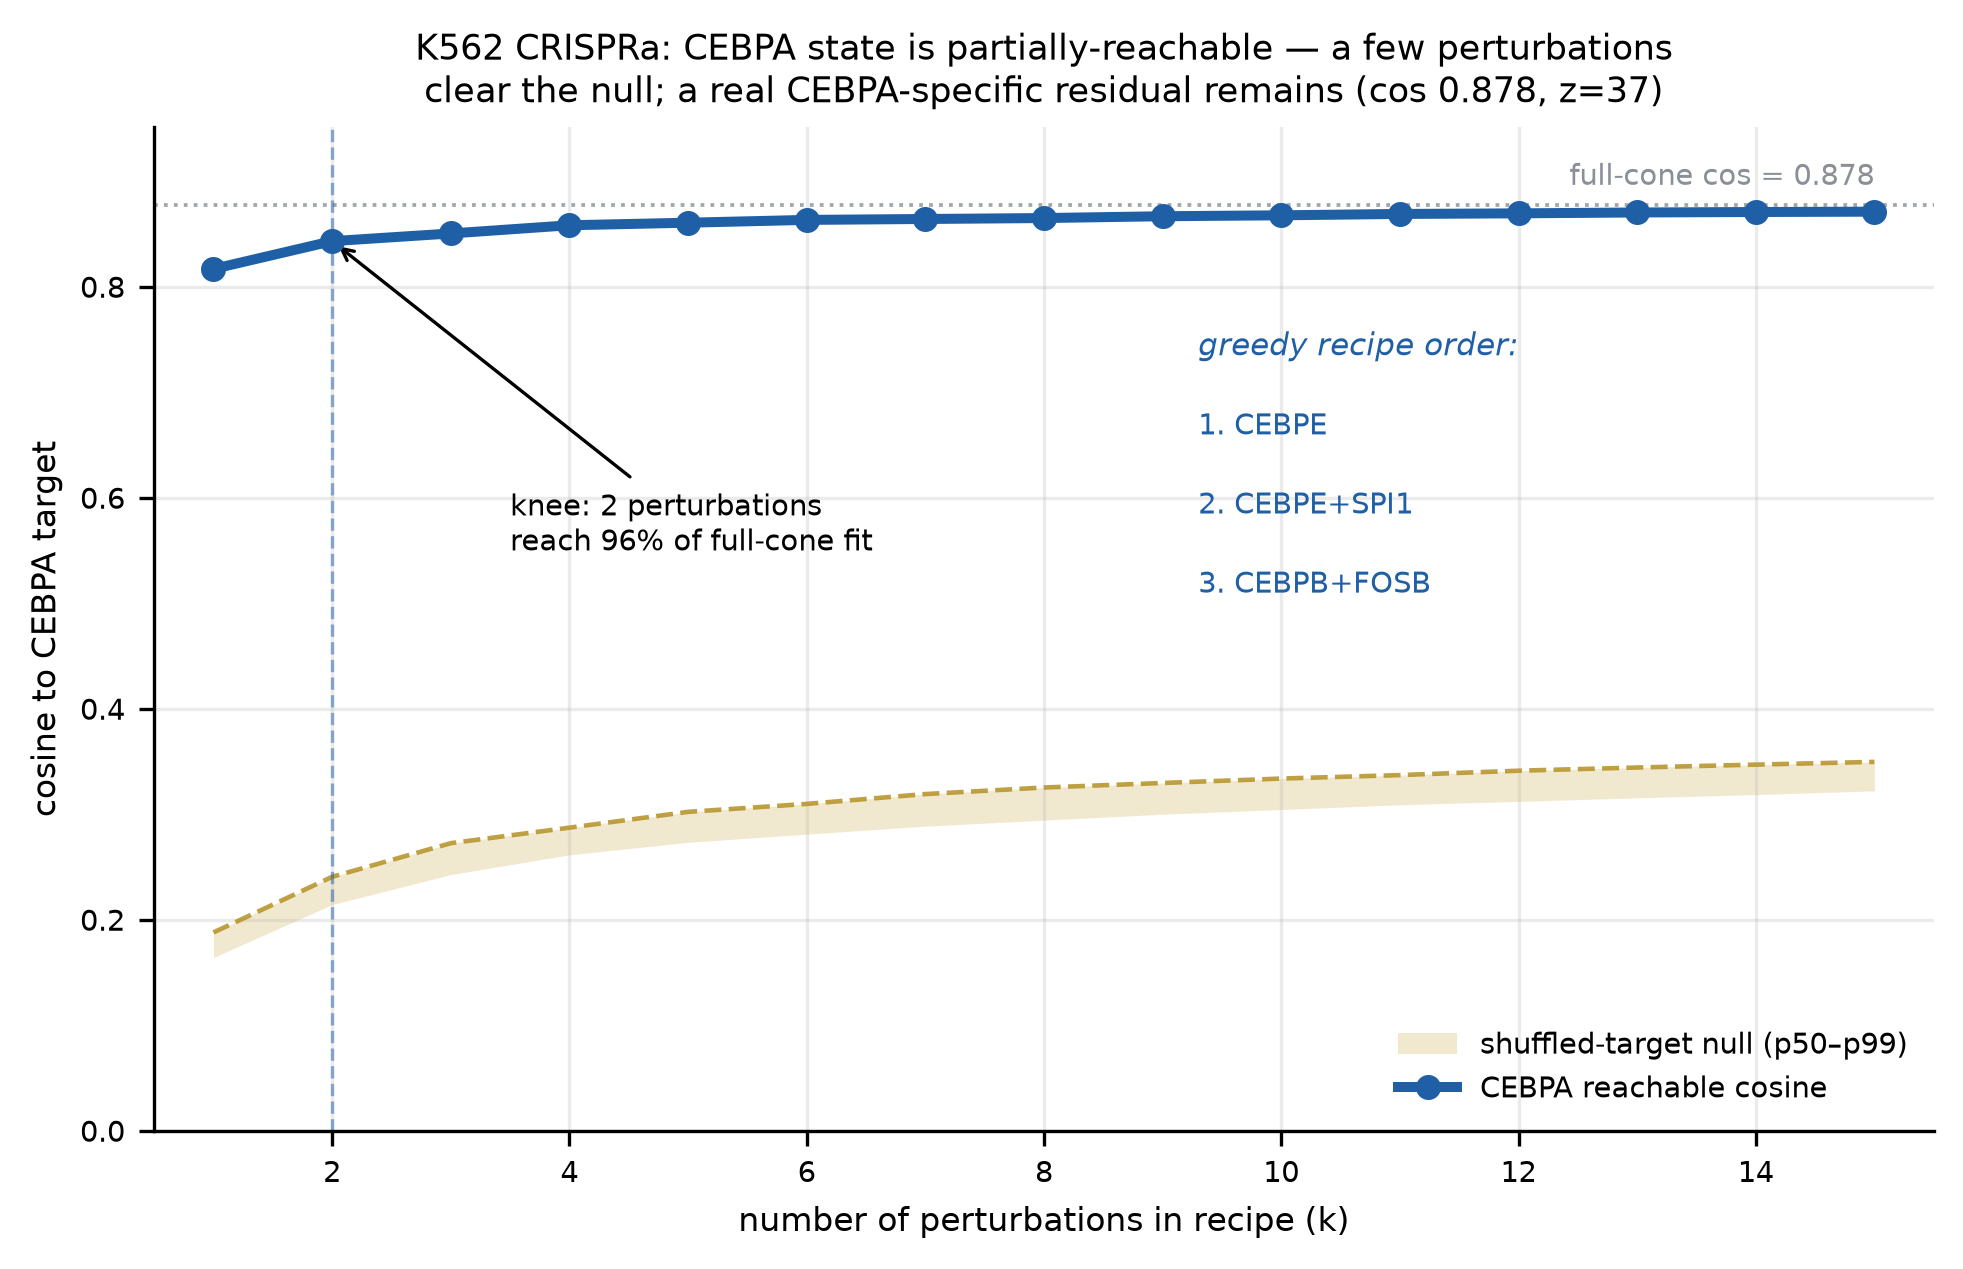

In [ ]:
# FIGURE 1 — reachability spectrum with shuffled-target null band.
fig, ax = plt.subplots(figsize=(6.6, 4.3))
ax.fill_between(np.arange(1,maxk+1), p50c, p99c, color="#e6d8a8", alpha=0.55, lw=0,
                label="shuffled-target null (p50–p99)")
ax.plot(np.arange(1,maxk+1), p99c, color="#b8962e", lw=1.1, ls="--", alpha=0.9)
ax.plot(kk, spec["cosine"], color=FOCAL, lw=2.4, marker='o', ms=5, label="CEBPA reachable cosine", zorder=5)
ax.axhline(res.reachable_cosine, color=NEU, lw=0.9, ls=':', alpha=0.8)
ax.text(maxk, res.reachable_cosine+0.012, f"full-cone cos = {res.reachable_cosine:.3f}",
        ha='right', va='bottom', fontsize=7, color=NEU)
ax.axvline(knee, color=FOCAL, lw=0.8, ls='--', alpha=0.5)
ax.annotate(f"knee: {knee} perturbations\nreach {knee_frac:.0%} of full-cone fit", xy=(knee, spec["cosine"][knee-1]),
            xytext=(knee+1.5, 0.55), fontsize=7, arrowprops=dict(arrowstyle='->', color='k', lw=0.8))
for i in range(3):
    ax.text(9.3, 0.66-0.075*i, f"{i+1}. {basis_labels[spec['order'][i]]}", fontsize=7, color=FOCAL)
ax.text(9.3, 0.66+0.075, "greedy recipe order:", fontsize=7.5, style='italic', color=FOCAL)
ax.set_xlabel("number of perturbations in recipe (k)"); ax.set_ylabel("cosine to CEBPA target")
ax.set_title("K562 CRISPRa: CEBPA state is partially-reachable — a few perturbations\n"
             f"clear the null; a real CEBPA-specific residual remains (cos {res.reachable_cosine:.3f}, z={null.z:.0f})",
             fontsize=8.5)
ax.set_xlim(0.5, maxk+0.5); ax.set_ylim(0, max(0.95, spec["cosine"].max()+0.08))
ax.legend(frameon=False, fontsize=7, loc='lower right')
fig.tight_layout(); fig.savefig(f"{FIG}/nb03_fig1_norman_spectrum.png", dpi=300, bbox_inches='tight')
plt.close(fig)
print("saved nb03_fig1_norman_spectrum.png")

### Activation certificate — what CEBPA uniquely supplies
The residual is not noise: it is a specific set of genes the CEBPA state demands *up* that no non-negative combination of other perturbations delivers. These are canonical myeloid-differentiation effectors (**MNDA, HP, VSIG4, ALOX5AP, NCF1, SIGLEC14**) — the part of the program the paralog recipe approaches but cannot fully install. This is the method's distinctive output: not just *how close*, but *what is missing*.

In [ ]:
# ACTIVATION CERTIFICATE — the genes the CEBPA state needs UP that no other-perturbation mix supplies.
cert = R.activation_certificate(res, d, gene_names=list(genes_hvg), top=25)
cert_df = pd.DataFrame({"gene": genes_hvg[cert.gene_index],
                        "target_z": cert.target_value,
                        "unmet_demand": cert.residual_value}).sort_values("unmet_demand", ascending=False)
print("=== ACTIVATION CERTIFICATE (CEBPA state) — top 12 genes only CEBPA supplies ===")
print(cert_df.head(12).to_string(index=False))
print("\n  These are myeloid-differentiation effectors (MNDA, HP, VSIG4, ALOX5AP, NCF1, SIGLEC14):")
print("  the CEBPA-specific program that the paralog recipe (CEBPE, SPI1, ...) approaches but cannot fully install.")

=== ACTIVATION CERTIFICATE (CEBPA state) — top 12 genes only CEBPA supplies ===
        gene  target_z  unmet_demand
        MNDA  9.874972      7.607018
          HP  9.460062      7.593261
       VSIG4  7.838354      6.512336
     ALOX5AP  8.103672      3.668324
       PILRA  6.535801      3.597620
        JAML  6.928832      3.420869
        NCF1  7.928925      3.360372
RP11-756H6.1  2.095486      3.160892
     SLC45A3  4.208638      3.155783
    SIGLEC14  5.638267      3.130515
RP11-10A14.4  1.895619      3.125667
        SRGN  7.343124      3.117166

  These are myeloid-differentiation effectors (MNDA, HP, VSIG4, ALOX5AP, NCF1, SIGLEC14):
  the CEBPA-specific program that the paralog recipe (CEBPE, SPI1, ...) approaches but cannot fully install.


### Additivity test — a validation only combinatorial data enables
When the cone method co-perturbs, it assumes effects add: the double A+B is modelled as **e_A + e_B**. The T-cell screen (singles only) could not test this. Here we compare each measured double against the sum of its two singles. Additivity turns out to be a **bounded approximation** (median cosine 0.71), not a law — and the strongly non-additive pairs are coherent genetic interactions (mitotic kinesins KIF18B+KIF2C; apoptotic BAK1+BCL2L11). The combinatorial data lets us *measure* the assumption instead of trusting it.

In [ ]:
# ADDITIVITY TEST — the validation the single-perturbation T-cell screen could NOT run.
# For each testable double A+B, compare the MEASURED double effect against the sum of its
# two single effects (raw log-FC). Additivity is the prior the cone method makes when it co-perturbs.
rows = []
for k,(dl,(i,j),ok) in enumerate(zip(doub_labels, comp_idx, comp_ok)):
    if not ok: continue
    meas = lfc_d[k]; add = lfc_s[i] + lfc_s[j]
    rows.append((dl, sing_labels[i], sing_labels[j], cos(meas, add),
                 float(np.linalg.norm(meas-add)/(np.linalg.norm(meas)+1e-12))))
add_df = pd.DataFrame(rows, columns=["double","A","B","cos_meas_add","rel_resid"])
med = add_df.cos_meas_add.median()
wellpred = (add_df.cos_meas_add>0.8).mean(); nonadd = (add_df.cos_meas_add<0.6).mean()
print("=== ADDITIVITY (measured double vs sum of its two singles, n=%d) ===" % len(add_df))
print(f"  median cosine(measured, additive) : {med:.3f}")
print(f"  well-predicted (cos>0.8)          : {wellpred:.0%}")
print(f"  strongly non-additive (cos<0.6)   : {nonadd:.0%}")
print("\n  most non-additive pairs (genetic interactions the additive prior misses):")
print(add_df.nsmallest(5,"cos_meas_add")[["double","cos_meas_add"]].to_string(index=False))
print("\n  => additivity is a BOUNDED approximation (median 0.71), not exact. The combinatorial data")
print("     lets us MEASURE the bound and flag the interacting pairs — a check singles-only data cannot do.")

=== ADDITIVITY (measured double vs sum of its two singles, n=126) ===
  median cosine(measured, additive) : 0.712
  well-predicted (cos>0.8)          : 18%
  strongly non-additive (cos<0.6)   : 16%

  most non-additive pairs (genetic interactions the additive prior misses):
      double  cos_meas_add
KIF18B+KIF2C      0.139770
BAK1+BCL2L11      0.178418
   PLK4+STIL      0.222706
 CBL+UBASH3A      0.311866
 BAK1+TMSB4X      0.322322

  => additivity is a BOUNDED approximation (median 0.71), not exact. The combinatorial data
     lets us MEASURE the bound and flag the interacting pairs — a check singles-only data cannot do.


### Figure 2 — decomposition, additivity, and certificate
*Generated live by the cell below.* (A) reachable/residual split with the cross-target discrimination z-scores; (B) the additivity distribution across 126 doubles; (C) the top certificate genes CEBPA uniquely supplies.

saved nb03_fig2_norman_decomposition.png


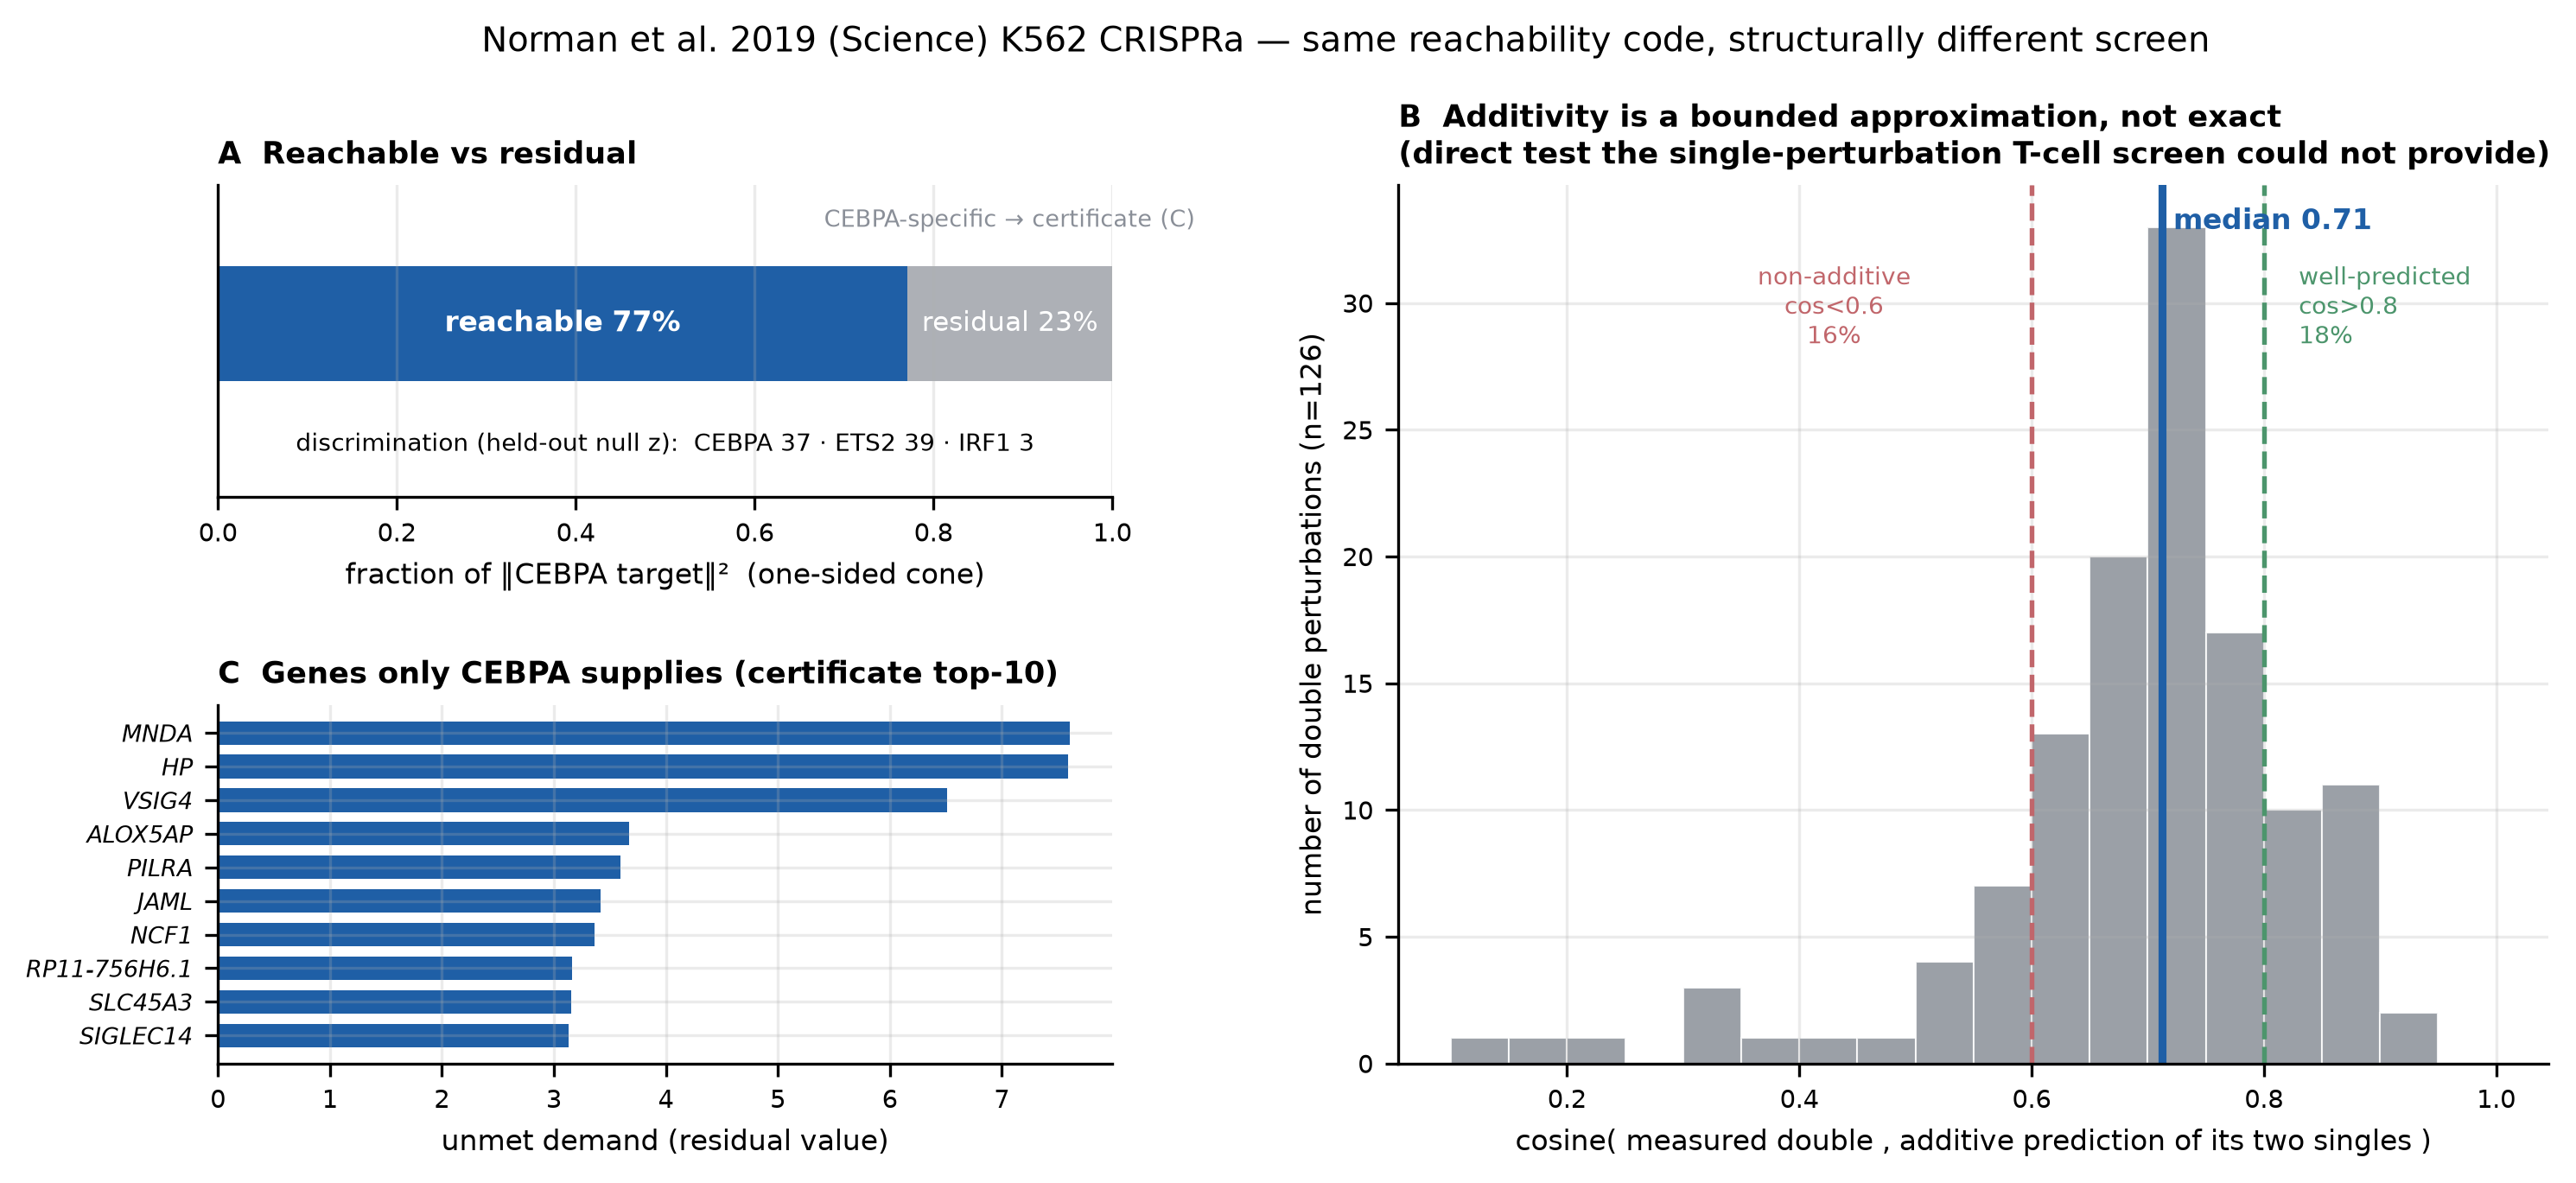

In [ ]:
# FIGURE 2 — three-panel: (A) reachable/residual split, (B) additivity distribution, (C) certificate top genes.
fig = plt.figure(figsize=(11.6, 4.4))
gs = fig.add_gridspec(2, 2, width_ratios=[1.05, 1.35], height_ratios=[1,1.15], hspace=0.62, wspace=0.28)

# (A) reachable vs residual bar
axA = fig.add_subplot(gs[0,0])
rf = dec["reachable_fraction"]
axA.barh([0], [rf], color=FOCAL, height=0.5, label=f"reachable {rf:.0%}")
axA.barh([0], [1-rf], left=[rf], color=NEU, height=0.5, alpha=0.7, label=f"residual {1-rf:.0%}")
axA.text(rf/2, 0, f"reachable {rf:.0%}", ha='center', va='center', color='white', fontsize=8, fontweight='bold')
axA.text(rf+(1-rf)/2, 0, f"residual {1-rf:.0%}", ha='center', va='center', color='white', fontsize=7.5)
axA.annotate("CEBPA-specific → certificate (C)", xy=(rf+(1-rf)/2, 0.42), ha='center', fontsize=6.5, color=NEU)
axA.set_xlim(0,1); axA.set_ylim(-0.75,0.6); axA.set_yticks([]); axA.set_xlabel("fraction of ‖CEBPA target‖²  (one-sided cone)")
axA.set_title("A  Reachable vs residual", fontsize=8.5, loc='left', fontweight='bold')
axA.text(0.5, -0.55, f"discrimination (held-out null z):  CEBPA {spread['CEBPA'][1]:.0f} · ETS2 {spread['ETS2'][1]:.0f} · IRF1 {spread['IRF1'][1]:.0f}",
         ha='center', fontsize=6.8, color='k')

# (C) certificate top-10
axC = fig.add_subplot(gs[1,0])
top = cert_df.head(10).iloc[::-1]
axC.barh(range(len(top)), top["unmet_demand"], color=FOCAL, height=0.7)
axC.set_yticks(range(len(top))); axC.set_yticklabels(top["gene"], fontsize=6.5, style='italic')
axC.set_xlabel("unmet demand (residual value)"); axC.set_title("C  Genes only CEBPA supplies (certificate top-10)", fontsize=8.5, loc='left', fontweight='bold')

# (B) additivity histogram
axB = fig.add_subplot(gs[:,1])
axB.hist(add_df["cos_meas_add"], bins=np.linspace(0.1,1.0,19), color=NEU, alpha=0.85, edgecolor='white', lw=0.5)
axB.axvline(med, color=FOCAL, lw=2.2, label=f"median {med:.2f}")
axB.axvline(0.8, color=GOOD, lw=1.3, ls='--'); axB.axvline(0.6, color=WARN, lw=1.3, ls='--')
ymax = axB.get_ylim()[1]
axB.text(0.83, ymax*0.82, f"well-predicted\ncos>0.8\n{wellpred:.0%}", color=GOOD, fontsize=6.8)
axB.text(0.43, ymax*0.82, f"non-additive\ncos<0.6\n{nonadd:.0%}", color=WARN, fontsize=6.8, ha='center')
axB.text(med+0.01, ymax*0.95, f"median {med:.2f}", color=FOCAL, fontsize=8, fontweight='bold')
axB.set_xlabel("cosine( measured double , additive prediction of its two singles )")
axB.set_ylabel(f"number of double perturbations (n={len(add_df)})")
axB.set_title("B  Additivity is a bounded approximation, not exact\n(direct test the single-perturbation T-cell screen could not provide)",
              fontsize=8.5, loc='left', fontweight='bold')
fig.suptitle("Norman et al. 2019 (Science) K562 CRISPRa — same reachability code, structurally different screen",
             fontsize=9.5, y=1.02)
fig.savefig(f"{FIG}/nb03_fig2_norman_decomposition.png", dpi=300, bbox_inches='tight')
plt.close(fig)
print("saved nb03_fig2_norman_decomposition.png")

---
## Part 2 — Leveraging other public datasets: a candidate catalog

The demo proves *one* transfer. The opportunity is broader: any assay that yields an (effect matrix, target direction) pair in a shared gene space is admissible input. Below are **13 real datasets**, every accession retrieved live from NCBI GEO this session (none asserted from memory), spanning five perturbation modalities. Each row carries the specific reachability question it would let you ask. Full detail with organisms, sizes, and access notes is in `results/dataset_catalog.csv`.

In [ ]:
# The candidate public-dataset catalog (survey half) — 13 real GEO accessions across 5 modalities.
cat = pd.read_csv(f"{RESULTS}/dataset_catalog.csv")
# collapse the verbose modality strings into 5 broad families for the count
def mod_family(m):
    m = m.lower()
    if "surface-protein" in m or "cite" in m: return "CRISPR + protein readout (CITE/ECCITE)"
    if "small-molecule" in m or "chemical" in m or "l1000" in m: return "chemical/drug"
    if "orf" in m or "overexpression" in m: return "ORF overexpression"
    if "cytokine" in m or "ligand" in m: return "cytokine/ligand"
    if "crispr" in m or "perturb" in m or "knockout" in m or "knockdown" in m: return "CRISPR Perturb-seq (RNA)"
    return "other"
n_fam = cat["modality"].map(mod_family).nunique()
print(f"candidate datasets: {len(cat)} across {n_fam} modality families\n")
show = cat[["accession","modality","cell_system","combinatorial","reachable_from_sandbox"]].copy()
show["modality"] = show["modality"].str.slice(0,34)
show["cell_system"] = show["cell_system"].str.slice(0,26)
print(show.to_string(index=False))

candidate datasets: 13 across 5 modality families

accession                           modality                cell_system combinatorial reachable_from_sandbox
GSE314342    Perturb-seq (CRISPRi knockdown) Primary human CD4+ T cells            no                    yes
GSE146194 Perturb-seq (CRISPRi + CRISPRa, si                 K562 (CML)           yes                    yes
 GSE90546    Perturb-seq (CRISPRi knockdown)                 K562 (CML)           yes                    yes
 GSE90063        Perturb-seq (Cas9 knockout)               BMDCs + K562            no                    yes
GSE153056 CRISPR knockout + surface-protein           THP-1 (monocytic)            no                    yes
GSE139944 Small-molecule / chemical perturba           A549, K562, MCF7            no                    yes
 GSE92742 Small-molecule + shRNA/ORF L1000 s            ~70+ cell lines            no                    yes
 GSE70138    Small-molecule L1000 signatures           ~cell-line panel      

---
## Part 3 — What it can resolve: application map and tractability grounding

The reachability certificate does more than score a target — it says *which genes* need to move and *in which direction*. Filtered through live target-tractability data (Open Targets / ChEMBL), that routes each biological goal to its intervention class: TF-activation certificates (no small-molecule tractability, zero approved drugs) are **cell-engineering / CRISPRa** problems, while enzyme-inhibition certificates (e.g. JAK1, 25 drugs) map onto **existing drugs** — a repurposing problem. This is the bridge from "is the state reachable?" to "how would you actually reach it?".

In [ ]:
# Therapeutic tractability grounding — from verdict to intervention modality.
tract = pd.read_csv(f"{RESULTS}/tractability_grounding.csv")
print("=== verdict -> modality (Open Targets / ChEMBL, live) ===")
for _,r in tract.iterrows():
    print(f"  {r['gene']:6s} {r['role'][:42]:42s} drugs={r['n_drugs']:>2}")
print("\n  TF-ACTIVATION certificates (TBX21/STAT4/FOXP3/GATA3): 0 SM tractability, 0 drugs -> CRISPRa / cell-engineering.")
print("  ENZYME-INHIBITION certificates (JAK1 25 drugs; DGKA ligandable) -> drug repurposing / med-chem.")
print("  => the reachability certificate, filtered by tractability, ROUTES each goal to its intervention class.")

=== verdict -> modality (Open Targets / ChEMBL, live) ===
  TBX21  Th1 master TF (certificate: ACTIVATE)      drugs= 0
  STAT4  Th1 signalling TF (certificate: ACTIVATE)  drugs= 0
  GATA3  Th2 master TF (would need KNOCKDOWN for Th drugs= 0
  FOXP3  Treg master TF (certificate: ACTIVATE)     drugs= 0
  JAK1   Signalling kinase (certificate: INHIBIT)   drugs=25
  DGKA   Enzyme (immuno-metabolic; certificate: INH drugs= 0

  TF-ACTIVATION certificates (TBX21/STAT4/FOXP3/GATA3): 0 SM tractability, 0 drugs -> CRISPRa / cell-engineering.
  ENZYME-INHIBITION certificates (JAK1 25 drugs; DGKA ligandable) -> drug repurposing / med-chem.
  => the reachability certificate, filtered by tractability, ROUTES each goal to its intervention class.


---
## Summary — the three questions, answered

**1. Is the methodology confined to this repo's dataset?**
No. Confinement is set by the input contract — a measured effect matrix **E** and a target **d** in a shared gene space — not by the dataset. The identical `reachability.py` produced a certified, null-calibrated, honest verdict on a K562 CRISPRa combinatorial screen that differs from the T-cell screen on cell type, modality, and design at once. The oracle also *discriminates* across targets (null-z 3→39), so a positive verdict is informative rather than automatic.

**2. Is there an opportunity to leverage other public datasets?**
Yes. Thirteen real, live-retrieved accessions across five modalities (genetic knockdown/knockout, CRISPRa, ORF overexpression, chemical/L1000, cytokine) are catalogued, each with the reachability question it enables — from additivity tests on combinatorial screens to directed-differentiation recipes on TF-overexpression atlases.

**3. What can it resolve in other biological problems?**
Four directions, each an instance of the same contract:
- **Cross-cell-type screens** — is a stimulus/polarization state reachable by knockdown in *this* cell type, and if not, which genes must be activated?
- **Drug-combination design** — the minimal non-negative drug mix reaching a state, or the reverse of a disease signature (LINCS L1000, sci-Plex).
- **Cell reprogramming / fate control** — which TF/cytokine combination reaches a target fate on a gain-of-function basis (Joung TF atlas, Immune Dictionary).
- **Disease reversal / target discovery** — target **d = −(disease signature)**; the certificate names the genes needing a non-drug modality, and tractability data routes each to CRISPRa vs small-molecule.

**The method's honesty is what ports.** The shuffled-target null and held-out-gene validation are properties of the algorithm, so the falsifiable reachable/outside verdict — and the constructive certificate when a state is out of reach — travel to every dataset above, not just the two demonstrated here.

*Artifacts written by this notebook and its companion analyses:* `results/norman_table1_verdict.csv` … `norman_table5_null_summary.csv`, `results/dataset_catalog.csv`, `results/tractability_grounding.csv`, the Technical Dossier (`docs/Technical_Dossier.md`, Appendix A - Generalizability), and figures under `docs/figures/`.